# Population info

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Basic load
df = pd.read_csv("../data/csv/5-gridded-population.csv")

In [4]:
df.shape

(684126, 3)

In [5]:
df.head()

,lon,lat,value
0,-75.326979,83.184431,1.560340e-05
1,-74.933626,83.184431,1.788235e-04
2,-74.540274,83.184431,3.061916e-04
3,-73.360217,83.184431,6.069001e-18
4,-72.966864,83.184431,3.072280e-06


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 684126 entries, 0 to 684125
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   lon     684126 non-null  float64
 1   lat     684126 non-null  float64
 2   value   684126 non-null  float64
dtypes: float64(3)
memory usage: 15.7 MB


In [7]:
df.describe()

,lon,lat,value
count,684126.000000,684126.000000,6.841260e+05
mean,11.560581,21.549993,1.074265e+04
std,79.610431,27.333522,5.121511e+04
min,-179.996975,-54.984269,5.965833e-19
25%,-61.045341,-0.849218,4.909102e+01
50%,20.682607,26.698031,6.286001e+02
75%,78.708902,43.392900,4.858488e+03
max,179.996975,83.184431,5.144518e+06


In [19]:
def plot_hist_population(df, threshold=1):
    df_clean = df[df['value'] > threshold]
    plt.figure(figsize=(10, 6))
    plt.hist(df_clean['value'], bins=500, color='blue', edgecolor='black')
    plt.title('Distribution of Population')
    plt.xlabel('Population')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

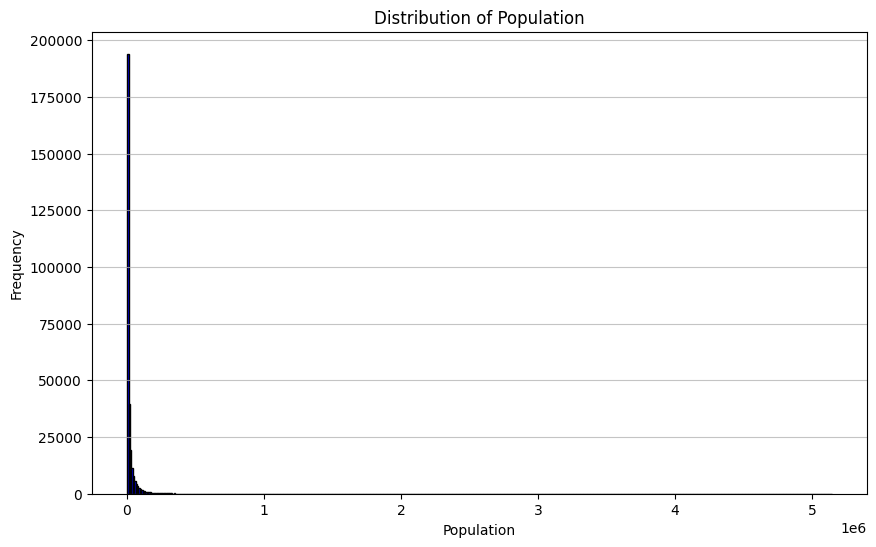

In [26]:
plot_hist_population(df, threshold=1000)

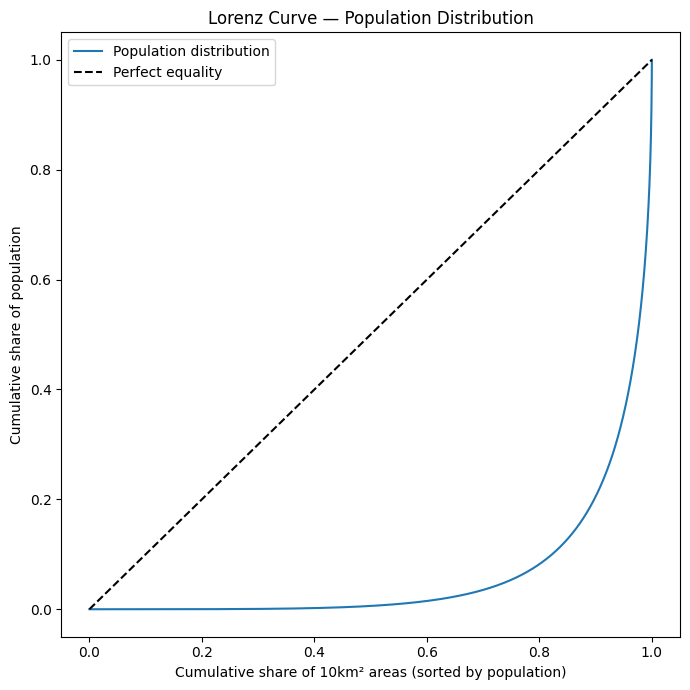

In [29]:
# Sort areas from least to most populated
sorted_pop = df["value"].sort_values().values

# Cumulative sums normalized to [0, 1]
cum_area = np.arange(1, len(sorted_pop) + 1) / len(sorted_pop)
cum_pop = np.cumsum(sorted_pop) / sorted_pop.sum()

plt.figure(figsize=(7, 7))
plt.plot(cum_area, cum_pop, label="Population distribution")
plt.plot([0, 1], [0, 1], "k--", label="Perfect equality")
plt.xlabel("Cumulative share of 10km² areas (sorted by population)")
plt.ylabel("Cumulative share of population")
plt.title("Lorenz Curve — Population Distribution")
plt.legend()
plt.tight_layout()
plt.show()


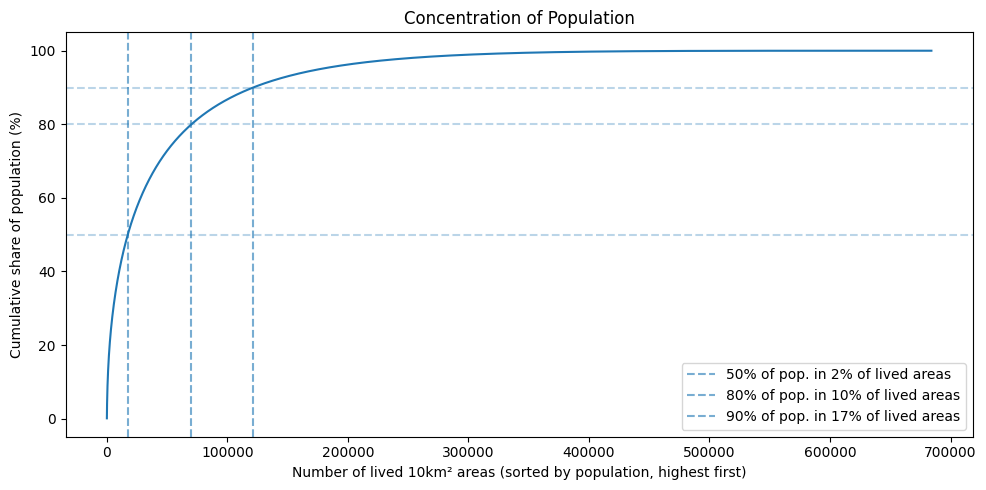

In [40]:
# Sort areas from most to least populated
sorted_pop = df["value"].sort_values(ascending=False).values

cum_area = np.arange(1, len(sorted_pop) + 1)  # absolute number of areas
cum_pop = np.cumsum(sorted_pop) / sorted_pop.sum()  # cumulative share of population

plt.figure(figsize=(10, 5))
plt.plot(cum_area, cum_pop * 100)
plt.xlabel("Number of lived 10km² areas (sorted by population, highest first)")
plt.ylabel("Cumulative share of population (%)")
plt.title("Concentration of Population")
plt.tight_layout()
for target in [0.5, 0.8, 0.9]:
    idx = np.searchsorted(cum_pop, target)
    plt.axvline(
        idx,
        linestyle="--",
        alpha=0.6,
        label=f"{int(target * 100)}% of pop. in {int(idx/cum_area[-1] * 100)}% of lived areas",
    )
    plt.axhline(target * 100, linestyle="--", alpha=0.3)

plt.legend()
plt.show()
